# Load Dataset

In [5]:
import re
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

pd.set_option('display.width', 140)

In [2]:
train_raw = pd.read_csv('data/train.csv')
test_raw = pd.read_csv('data/test.csv')

train_raw.shape, test_raw.shape

((916, 12), (393, 11))

In [3]:
train_raw.columns

Index(['passengerid', 'survived', 'pclass', 'name', 'gender', 'age', 'sibsp', 'parch', 'ticket', 'fare', 'cabin', 'embarked'], dtype='str')

## Feature 생성 (1) - Name -> Title

이름의 호칭(Mr/Miss/Mrs/Master/기타)은 나이·성별·사회적 지위를 함축해 생존과 상관관계가 높다 (`target과 상관관계가 높은 새로운 features 생성`).

In [4]:
TITLE_MAP = {
    'Mlle': 'Miss', 'Ms': 'Miss',
    'Mme': 'Mrs',
    'Mr': 'Mr', 'Miss': 'Miss', 'Mrs': 'Mrs', 'Master': 'Master',
}
RARE_TITLE = 'Rare'

def extract_title(name: str) -> str:
    m = re.search(r',\s*([^\.]*)\.', name)
    raw = m.group(1).strip() if m else 'Unknown'
    return TITLE_MAP.get(raw, RARE_TITLE if raw not in ('Mr', 'Miss', 'Mrs', 'Master') else raw)

for _df in (train_raw, test_raw):
    _df['title'] = _df['name'].apply(extract_title)

train_raw['title'].value_counts()

title
Mr        528
Miss      187
Mrs       138
Master     42
Rare       21
Name: count, dtype: int64

## 필요없는 컬럼 제거

`name`, `ticket`은 위에서 필요한 정보(title)를 뽑아냈으므로 제거한다.

`cabin`은 결측치 비율이 20% 이상이므로 컬럼 자체를 제거한다 (아래 결측치 분석 참고).

In [5]:
cabin_missing_ratio = train_raw['cabin'].isnull().mean()
print(f'cabin 결측 비율: {cabin_missing_ratio:.1%}  ->  20% 이상이므로 컬럼 삭제')

df = train_raw.drop(columns=['name', 'ticket', 'cabin'])
test_df = test_raw.drop(columns=['name', 'ticket', 'cabin'])

df.shape, test_df.shape

cabin 결측 비율: 78.4%  ->  20% 이상이므로 컬럼 삭제


((916, 10), (393, 9))

## Target

In [6]:
# 각 class간의 비율 확인 -> 이진 분류, 다소 불균형(약 62:38)이지만 심하지는 않음
df['survived'].value_counts() / df.shape[0]

survived
0    0.622271
1    0.377729
Name: count, dtype: float64

## 평가 & 학습 데이터셋

Kaggle `test.csv`에는 정답(`survived`)이 없으므로, 모델 검증은 `train.csv`를 다시 분리해서 진행하고 `test.csv`는 최종 제출 예측에만 사용한다.

In [7]:
from common.utils import train_test_split_by_target

train, valid = train_test_split_by_target(df)

train.shape, valid.shape

((687, 10), (229, 10))

# EDA

In [8]:
train.info()

<class 'pandas.DataFrame'>
Index: 687 entries, 595 to 636
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   passengerid  687 non-null    int64  
 1   survived     687 non-null    int64  
 2   pclass       687 non-null    int64  
 3   gender       687 non-null    str    
 4   age          561 non-null    float64
 5   sibsp        687 non-null    int64  
 6   parch        687 non-null    int64  
 7   fare         687 non-null    float64
 8   embarked     687 non-null    str    
 9   title        687 non-null    str    
dtypes: float64(2), int64(5), str(3)
memory usage: 59.0 KB


# Data Preprocessing

## data cleaning

In [9]:
# row 중복 제거 (검증셋은 학습에 쓰이지 않으므로 대상에서 제외)
print(f'before: {train.shape}')

train = train.drop_duplicates()
print(f'after: {train.shape}')

before: (687, 10)
after: (687, 10)


In [10]:
# 결측치 확인
null_tr = train.isnull().sum()

(null_tr[null_tr > 0] / train.shape[0]).sort_values(ascending=False)

age    0.183406
dtype: float64

## 결측치 대체

`age`는 결측 비율이 20% 미만이므로 삭제 대신 대체한다. 단순 평균 대신 `target`/`features`(pclass, title)로 그룹핑한 통계값을 사용한다.

`embarked`(train), `fare`(test)는 결측이 매우 적어 각각 최빈값 / pclass 그룹 중앙값으로 채운다.

In [11]:
age_group_median = train.groupby(['pclass', 'title'])['age'].median()
overall_age_median = train['age'].median()

def fill_age(row, ref):
    if pd.notnull(row['age']):
        return row['age']
    key = (row['pclass'], row['title'])
    return ref.get(key, overall_age_median) if key in ref.index else overall_age_median

print(f"before: {train['age'].isnull().sum()} / {valid['age'].isnull().sum()} / {test_df['age'].isnull().sum()}")

for _d in (train, valid, test_df):
    _d['age'] = _d.apply(lambda r: fill_age(r, age_group_median), axis=1)

print(f"after:  {train['age'].isnull().sum()} / {valid['age'].isnull().sum()} / {test_df['age'].isnull().sum()}")

before: 126 / 54 / 83
after:  0 / 0 / 0


In [12]:
embarked_mode = train['embarked'].mode().values[0]
fare_group_median = train.groupby('pclass')['fare'].median()

for _d in (train, valid, test_df):
    _d['embarked'] = _d['embarked'].fillna(embarked_mode)
    _d['fare'] = _d.apply(
        lambda r: fare_group_median[r['pclass']] if pd.isnull(r['fare']) else r['fare'], axis=1
    )

print(f"결측치 총합 -> train:{train.isnull().sum().sum()} valid:{valid.isnull().sum().sum()} test:{test_df.isnull().sum().sum()}")

결측치 총합 -> train:0 valid:0 test:0


## Feature 생성 (2)

가족 규모, 동승자 유무, 성인 남성 여부 등 도메인 지식 기반 파생 변수를 추가한다.

In [13]:
for _d in (train, valid, test_df):
    _d['family_size'] = _d['sibsp'] + _d['parch'] + 1
    _d['alone'] = _d['family_size'] == 1
    _d['who'] = np.where(_d['age'] < 16, 'child', np.where(_d['gender'] == 'male', 'man', 'woman'))
    _d['adult_male'] = _d['who'] == 'man'

train[['family_size', 'alone', 'who', 'adult_male']].head()

,family_size,alone,who,adult_male
595,2,False,child,False
148,1,True,man,True
347,3,False,child,False
731,3,False,woman,False
457,1,True,man,True


# 차원 축소 (features vs features)

`sibsp`, `parch`, `family_size`는 서로 상관관계가 매우 높다(0.41~0.89). 이렇게 상관관계가 높은 features는 overfitting의 원인이 되므로, 단순 삭제 대신 PCA로 1개 성분으로 축소해 중복 정보를 줄인다.

In [14]:
num_cols = ['age', 'sibsp', 'parch', 'fare', 'family_size']
corr = train[num_cols].corr()
corr

,age,sibsp,parch,fare,family_size
age,1.000000,-0.222715,-0.203597,0.177692,-0.254559
sibsp,-0.222715,1.000000,0.408164,0.158457,0.886410
parch,-0.203597,0.408164,1.000000,0.185533,0.784387
fare,0.177692,0.158457,0.185533,1.000000,0.201739
family_size,-0.254559,0.886410,0.784387,0.201739,1.000000


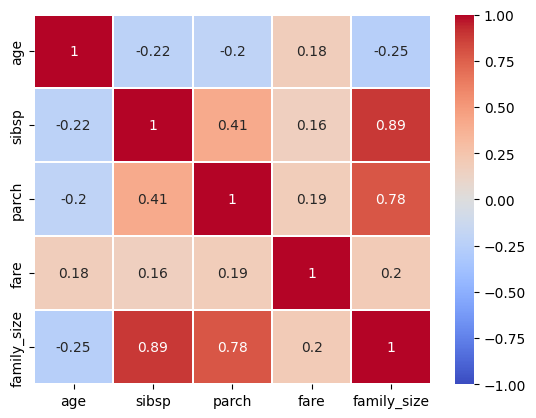

In [15]:
import seaborn as sns

sns.heatmap(
    data=corr, vmin=-1, vmax=1, annot=True, linewidths=0.2, cmap='coolwarm'
)
plt.show()

In [16]:
from sklearn.decomposition import PCA

pca_cols = ['sibsp', 'parch', 'family_size']

pca = PCA(n_components=1, random_state=42)
pca.fit(train[pca_cols])
print(f'변환율: {pca.explained_variance_ratio_}')

변환율: [0.88670858]


In [17]:
print(f'before: {train.shape}')

for _d in (train, valid, test_df):
    _comp = pca.transform(_d[pca_cols])
    _d['family_pca'] = _comp[:, 0]
    _d.drop(columns=pca_cols, inplace=True)

print(f'after: {train.shape}')
train.head()

before: (687, 14)
after: (687, 12)


,passengerid,survived,pclass,gender,age,fare,embarked,title,alone,who,adult_male,family_pca
595,595,0,3,male,0.83,9.3500,S,Master,False,child,False,0.103442
148,148,0,3,male,25.00,8.0500,S,Mr,True,man,True,-1.015093
347,347,0,3,female,9.00,15.2458,C,Miss,False,child,False,1.412149
731,731,1,3,female,24.00,16.7000,S,Mrs,False,woman,False,1.221978
457,457,0,2,male,44.00,13.0000,S,Mr,True,man,True,-1.015093


In [18]:
# feature-target 상관관계 확인 (참고용 - 범주형은 코드값으로 임시 변환)
_insp = train.copy()
for c in ['gender', 'embarked', 'title', 'who']:
    _insp[c] = _insp[c].astype('category').cat.codes

_insp.drop(columns=['passengerid']).corr()['survived'].sort_values(ascending=False)

survived      1.000000
who           0.482737
fare          0.173310
family_pca    0.057430
age          -0.051747
title        -0.053224
embarked     -0.116733
pclass       -0.199133
alone        -0.205431
adult_male   -0.680848
gender       -0.718704
Name: survived, dtype: float64

# Modeling

In [19]:
from common.modeling import Modeling, BoostModelType

/usr/local/lib/python3.11/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Check Dataset before Modeling

In [20]:
cat_cols = ['pclass', 'gender', 'embarked', 'title', 'who', 'adult_male', 'alone']

modeling = Modeling(
    x_tr=train.drop(['survived', 'passengerid'], axis=1),
    y_tr=train['survived'],
    cat_cols=cat_cols,
)

In [21]:
modeling.fit_evaluation(
    x_te=valid.drop(['survived', 'passengerid'], axis=1),
    y_te=valid['survived'],
)


training..:   0%|          | 0/3 [00:00<?, ?it/s]


training..:  67%|██████▋   | 2/3 [00:00<00:00, 12.22it/s]


training..: 100%|██████████| 3/3 [00:01<00:00,  1.68it/s]

In [22]:
modeling.get_best_model()

{'model': CatBoostClassifier(cat_features=['pclass', 'gender', 'embarked', 'title', 'who', 'adult_male', 'alone'], verbose=0),
 'model_name': 'CatBoostClassifier',
 'hpo': {'verbose': 0,
  'cat_features': ['pclass',
   'gender',
   'embarked',
   'title',
   'who',
   'adult_male',
   'alone']},
 'train_score': 0.8749054224464061,
 'test_score': 0.8405838347698813,
 'score_type': 'get_auc_score'}

# Evaluation

In [23]:
best = modeling.get_best_model()
print(f"훈련용 평가지표({best['score_type']}): {best['train_score']:.4f} / 검증용 평가지표({best['score_type']}): {best['test_score']:.4f}")

훈련용 평가지표(get_auc_score): 0.8749 / 검증용 평가지표(get_auc_score): 0.8406


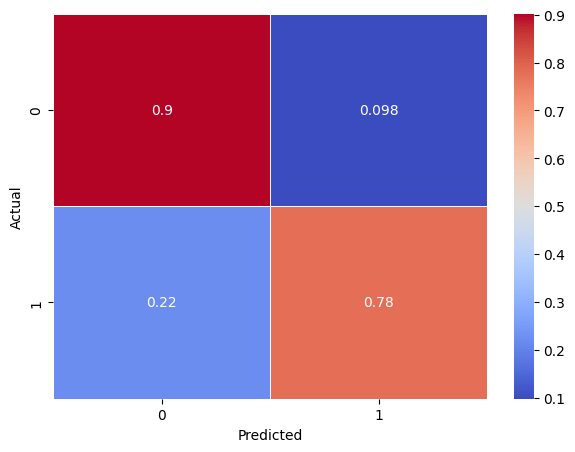

In [24]:
from common.evaluation_plots import show_norm_conf_mx

pred_valid = modeling.predict_by_best_model(valid.drop(['survived', 'passengerid'], axis=1))

show_norm_conf_mx(y=valid['survived'], pred=pred_valid)

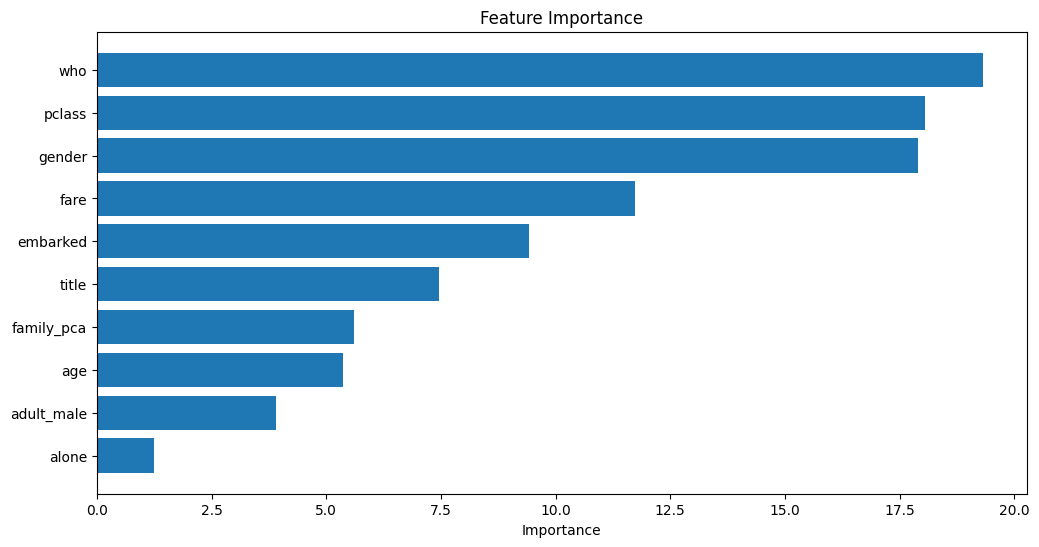

In [25]:
BoostModelType.show_plot_importance(modeling.get_best_model()['model'])

# 제출 파일 생성

Kaggle `test.csv`(정답 없음)에 동일한 전처리를 적용한 뒤, 검증에서 가장 좋았던 모델로 예측한다.

평가 기준이 AUC이고 제공된 제출 포맷(`passengerid,survived`, 값이 `0.5` 같은 확률)도 확률 점수를 기대하므로, `predict_by_best_model`(0/1 하드 예측)이 아니라 best model 객체에서 직접 `predict_proba`를 사용해 생존 확률을 제출한다. (`common/modeling.py`는 수정하지 않고, 반환된 model 객체의 표준 메서드만 사용)

In [26]:
best_model = modeling.get_best_model()['model']

x_test = test_df.drop(columns=['passengerid'])
proba_test = best_model.predict_proba(x_test)[:, 1]

submission = pd.DataFrame({
    'passengerid': test_df['passengerid'],
    'survived': proba_test,
})

submission.to_csv('data/submission.csv', index=False)
submission.head()

,passengerid,survived
0,916,0.830246
1,917,0.882015
2,918,0.911952
3,919,0.070439
4,920,0.976861


In [27]:
submission['survived'].describe()

count    393.000000
mean       0.381770
std        0.380096
min        0.028319
25%        0.075127
50%        0.119378
75%        0.818976
max        0.992281
Name: survived, dtype: float64